In [18]:
from trendspy import Trends

tr = Trends()
tendencias = tr.interest_over_time(
    ["CPI", "inflation report"],
    timeframe="2023-01-01 2026-08-06",
    geo="US"
)
print(tendencias.head())
print(tendencias.shape)

            CPI  inflation report  isPartial
time [UTC]                                  
2023-01-01   17                 1      False
2023-01-08   70                 7      False
2023-01-15   16                 1      False
2023-01-22   17                 1      False
2023-01-29   19                 1      False
(188, 3)


In [19]:
tendencias["atencao_bruta"] = tendencias[["CPI", "inflation report"]].mean(axis=1)
print(tendencias[["atencao_bruta"]].head())

            atencao_bruta
time [UTC]               
2023-01-01            9.0
2023-01-08           38.5
2023-01-15            8.5
2023-01-22            9.0
2023-01-29           10.0


In [24]:
print(eventos["data"].dtype)
print(tendencias["data"].dtype)

datetime64[us]
datetime64[ns]


In [25]:
import pandas as pd

eventos = pd.read_csv("../data/eventos.csv")
eventos["data"] = pd.to_datetime(eventos["data"])

tendencias = tendencias.rename(columns={"time [UTC]": "data"})
tendencias["data"] = pd.to_datetime(tendencias["data"])

tendencias = tendencias.sort_values("data")
eventos = eventos.sort_values("data")

eventos["data"] = eventos["data"].astype("datetime64[ns]")
tendencias["data"] = tendencias["data"].astype("datetime64[ns]")

eventos_ian = pd.merge_asof(eventos, tendencias[["data", "atencao_bruta"]], on="data", direction="backward")
print(eventos_ian[["data", "surpresa_zscore", "atencao_bruta"]])

         data  surpresa_zscore  atencao_bruta
0  2023-03-14         0.000000           23.5
1  2023-04-12        -1.007506           29.5
2  2023-05-10         0.000000           22.5
3  2023-06-13        -1.007506           20.5
4  2023-07-12        -1.007506           23.5
5  2023-08-10         0.000000           24.0
6  2023-09-13         0.000000           20.5
7  2023-10-12         1.007506           18.0
8  2023-11-14        -1.007506           22.0
9  2023-12-12         1.007506           17.0
10 2024-01-11         1.007506           17.5
11 2024-02-13         1.007506           26.5
12 2024-03-12         0.000000           21.0
13 2024-04-10         1.007506           28.5
14 2024-05-15        -1.007506           24.5
15 2024-06-12        -1.007506           19.5
16 2024-07-11        -2.015012           24.0
17 2024-08-14         0.000000           25.0
18 2024-09-11         0.000000           18.5
19 2024-10-10         1.007506           15.5
20 2024-11-13         0.000000    

In [26]:
minimo = eventos_ian["atencao_bruta"].min()
maximo = eventos_ian["atencao_bruta"].max()

eventos_ian["IAN"] = (eventos_ian["atencao_bruta"] - minimo) / (maximo - minimo)
print(eventos_ian[["data", "surpresa_zscore", "IAN"]])

         data  surpresa_zscore       IAN
0  2023-03-14         0.000000  0.218391
1  2023-04-12        -1.007506  0.356322
2  2023-05-10         0.000000  0.195402
3  2023-06-13        -1.007506  0.149425
4  2023-07-12        -1.007506  0.218391
5  2023-08-10         0.000000  0.229885
6  2023-09-13         0.000000  0.149425
7  2023-10-12         1.007506  0.091954
8  2023-11-14        -1.007506  0.183908
9  2023-12-12         1.007506  0.068966
10 2024-01-11         1.007506  0.080460
11 2024-02-13         1.007506  0.287356
12 2024-03-12         0.000000  0.160920
13 2024-04-10         1.007506  0.333333
14 2024-05-15        -1.007506  0.241379
15 2024-06-12        -1.007506  0.126437
16 2024-07-11        -2.015012  0.229885
17 2024-08-14         0.000000  0.252874
18 2024-09-11         0.000000  0.103448
19 2024-10-10         1.007506  0.034483
20 2024-11-13         0.000000  0.000000
21 2024-12-11         0.000000  0.034483
22 2025-01-15         0.000000  0.149425
23 2025-02-12   

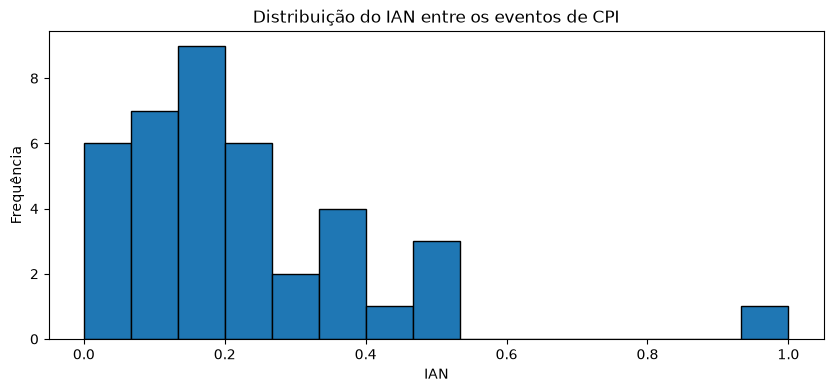

In [27]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 4))
plt.hist(eventos_ian["IAN"], bins=15, edgecolor="black")
plt.xlabel("IAN")
plt.ylabel("Frequência")
plt.title("Distribuição do IAN entre os eventos de CPI")
plt.show()

In [ ]:
print(eventos_ian.sort_values("IAN", ascending=False).head(5))

   indicador       data  actual  forecast  diferenca  surpresa_zscore  \
37   CPI_EUA 2026-06-10     0.5       0.5        0.0         0.000000   
34   CPI_EUA 2026-03-11     0.3       0.3        0.0         0.000000   
33   CPI_EUA 2026-02-13     0.2       0.3       -0.1        -1.007506   
36   CPI_EUA 2026-05-12     0.6       0.6        0.0         0.000000   
29   CPI_EUA 2025-08-12     0.2       0.2        0.0         0.000000   

    atencao_bruta       IAN  
37           57.5  1.000000  
34           36.5  0.517241  
33           36.5  0.517241  
36           34.5  0.471264  
29           34.0  0.459770  


Outlier no IAN (evento de 10/06/2026)

A normalização Min-Max do IAN é sensível a valores extremos. O evento de
10/06/2026 (CPI de maio/2026) apresentou atenção de busca bem acima dos
demais, coincidindo com um período de convergência de notícias econômicas
relevantes (CPI de maio veio acima do esperado, reunião do Fed com tom
hawkish sob a nova liderança de Kevin Warsh, tensões geopolíticas EUA-Irã
afetando preços de energia). Optou-se por manter a normalização padrão
(Min-Max sobre o range completo), por ser fiel à fórmula especificada e
por o outlier representar um evento real, não ruído de dado.